# GRPO Detection Training: Qwen3-8B on AVCORP

SFT (1 epoch), then GRPO with five rule-based rewards. The model plays the Investigator in a 5-player Avalon game and writes a JSON reasoning trace (abductions, suspicion, ToM beliefs, statement, deduction).

bf16 Qwen3-8B with LoRA (r=32, alpha=64) on all linear layers; 1,000 rows split 900/100 **by game**.

## Install

Packages and the Hugging Face cache go to `/share` (home has a ~10K-file quota). `torch` comes from the container.

In [1]:
# Keep pip packages and the HF cache on /share; home has a ~10K-file quota.
import os
import sys
import site

SHARE = "/share/mpsingh/fsaad"          # verify with `groups` if this path is wrong
USER_BASE = os.path.join(SHARE, "python-packages")

os.environ["PYTHONUSERBASE"] = USER_BASE
os.environ["HF_HOME"] = os.path.join(SHARE, "hf_cache")
# pip's wheel cache goes to /share too
os.environ["PIP_CACHE_DIR"] = os.path.join(SHARE, "pip", "cache")

if not os.path.isdir(SHARE):
    print(f"WARNING: {SHARE} does not exist. Run `groups` and correct SHARE above.")

# make this interpreter see packages installed to the new user base
_user_site = os.path.join(
    USER_BASE, "lib", f"python{sys.version_info.major}.{sys.version_info.minor}", "site-packages"
)
os.makedirs(_user_site, exist_ok=True)
site.addsitedir(_user_site)

# put our site-packages first so the pinned versions win over the container's
if _user_site in sys.path:
    sys.path.remove(_user_site)
sys.path.insert(0, _user_site)

print(f"Python     : {sys.version.split()[0]}")
print(f"pip target : {_user_site}")
print(f"HF_HOME    : {os.environ['HF_HOME']}")
print()

# --no-cache-dir only: --force-reinstall would also replace the container's torch
%pip install -qqq --no-cache-dir \
    datasets==3.2.0 \
    transformers==4.56.1 \
    trl==0.24.0 \
    peft==0.14.0 \
    accelerate==1.4.0 \
    scikit-learn \
    wandb \
    matplotlib \
    --progress-bar off


# ---- check the pinned stack; torch comes from the container
import importlib

_expected = {
    "datasets": "3.2.0",
    "transformers": "4.56.1",
    "trl": "0.24.0",
    "peft": "0.14.0",
    "accelerate": "1.4.0",
}
_ok = True
for _name, _want in _expected.items():
    try:
        _m = importlib.import_module(_name)
        _got = getattr(_m, "__version__", "unknown")
        _flag = "ok  " if _got == _want else "WRONG"
        if _got != _want:
            _ok = False
        print(f"{_flag} {_name:13s} {_got:10s} (want {_want})")
        print(f"      from {_m.__file__}")
    except Exception as _e:
        _ok = False
        print(f"FAIL  {_name:13s} {type(_e).__name__}: {_e}")

import torch
print(f"      torch         {torch.__version__} | CUDA available: {torch.cuda.is_available()} (container-provided)")
print()
print("Environment OK, continue." if _ok else "Environment NOT clean: fix before training.")


Python     : 3.12.11
pip target : /share/mpsingh/fsaad/python-packages/lib/python3.12/site-packages
HF_HOME    : /share/mpsingh/fsaad/hf_cache



Note: you may need to restart the kernel to use updated packages.


ok   datasets      3.2.0      (want 3.2.0)
      from /share/mpsingh/fsaad/python-packages/lib/python3.12/site-packages/datasets/__init__.py


ok   transformers  4.56.1     (want 4.56.1)
      from /share/mpsingh/fsaad/python-packages/lib/python3.12/site-packages/transformers/__init__.py
ok   trl           0.24.0     (want 0.24.0)
      from /share/mpsingh/fsaad/python-packages/lib/python3.12/site-packages/trl/__init__.py


ok   peft          0.14.0     (want 0.14.0)
      from /share/mpsingh/fsaad/python-packages/lib/python3.12/site-packages/peft/__init__.py
ok   accelerate    1.4.0      (want 1.4.0)
      from /share/mpsingh/fsaad/python-packages/lib/python3.12/site-packages/accelerate/__init__.py
      torch         2.7.1+cu128 | CUDA available: True (container-provided)

Environment OK, continue.


## Imports

In [2]:
import os

# single GPU; must be set before importing torch
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

# fewer fragmentation OOMs from the large-vocab logits
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import json
import re
import shutil
import torch
import pandas as pd
from pathlib import Path
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model
from trl import GRPOConfig, GRPOTrainer, SFTTrainer, SFTConfig

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# bf16 only with native tensor-core support (no emulation fallback)
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported(including_emulation=False)
COMPUTE_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}: {props.name} | {props.total_memory / 1e9:.1f} GB VRAM | compute capability {props.major}.{props.minor}")
    if USE_BF16:
        print("  -> Native bf16 tensor core support detected (Ampere or newer). Using bf16 throughout.")
    else:
        print("  -> No native bf16 tensor core support detected (pre-Ampere, e.g. Turing/Volta). Using fp16 throughout.")
else:
    print("  -> No CUDA device found; nothing past this cell will run without a GPU.")

print(f"COMPUTE_DTYPE = {COMPUTE_DTYPE}")

# the model download needs ~16 GB
free_gb = shutil.disk_usage(os.path.expanduser("~")).free / 1e9
print(f"\nFree disk space in home directory: {free_gb:.1f} GB")
if free_gb < 25:
    print("  -> WARNING: likely not enough room for the base model download plus checkpoints.")
    print("     Clear space first, or redirect the HF cache with:")
    print("     os.environ['HF_HOME'] = '/path/with/more/room'  (set before loading the model/tokenizer)")


PyTorch: 2.7.1+cu128
CUDA available: True
GPU 0: NVIDIA H100 PCIe | 85.0 GB VRAM | compute capability 9.0
  -> Native bf16 tensor core support detected (Ampere or newer). Using bf16 throughout.
COMPUTE_DTYPE = torch.bfloat16

Free disk space in home directory: 107286.2 GB


## Load AVCORP

Verify all 1,000 reasoning traces parse as valid JSON before doing anything else.

In [3]:
DATA_PATH = Path("Deception-Dataset.csv")

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nRound distribution:")
print(df['round_id'].value_counts().sort_index())
print(f"\nRole distribution (investigator rotates across all five players):")
print(df['role_id'].value_counts().sort_index())

parse_errors = 0
for i, rg in enumerate(df['reasoning_gold']):
    try:
        json.loads(rg)
    except Exception:
        parse_errors += 1
        print(f"  Parse error at row {i}")
print(f"\nJSON parse errors: {parse_errors} / {len(df)}")

Shape: (1000, 10)
Columns: ['game_id', 'round_id', 'role_id', 'llm_alignment', 'player_roles', 'public_history', 'prior_summary_gold', 'discussion_log', 'matrix_tactic_scale', 'reasoning_gold']

Round distribution:


round_id
1    250
2    250
3    250
4    150
5    100
Name: count, dtype: int64

Role distribution (investigator rotates across all five players):
role_id
P1    200
P2    200
P3    200
P4    200
P5    200
Name: count, dtype: int64

JSON parse errors: 0 / 1000


## Context Window

Each prompt holds the investigator's own traces from the last 2 rounds and the public history of the current round and the 2 before it. The discussion is the current round only.

In [4]:
def build_reasoning_chain_lookup(df: pd.DataFrame, window: int = 2) -> dict:
    """Map (game_id, round_id) to the investigator's traces from the last `window` rounds of the game."""
    lookup = {}
    for game_id, group in df.groupby('game_id'):
        sorted_group = group.sort_values('round_id')
        accumulated = []
        for _, row in sorted_group.iterrows():
            rid = int(row['round_id'])
            lookup[(game_id, rid)] = list(accumulated[-window:])
            accumulated.append({
                'round_id': rid,
                'reasoning_gold': row['reasoning_gold'],
            })
    return lookup


def build_public_history_window(df: pd.DataFrame, window: int = 3) -> dict:
    """Map (game_id, round_id) to the public history of the current round and the `window - 1` before it."""
    lookup = {}
    for game_id, group in df.groupby('game_id'):
        sorted_group = group.sort_values('round_id')
        rows = list(sorted_group.iterrows())
        for i, (_, row) in enumerate(rows):
            rid = int(row['round_id'])
            start = max(0, i - (window - 1))
            parts = [f"[R{int(r['round_id'])}] {r['public_history'].strip()}" for _, r in rows[start:i + 1]]
            lookup[(game_id, rid)] = "\n".join(parts)
    return lookup


reasoning_chain_lookup = build_reasoning_chain_lookup(df)
public_history_lookup = build_public_history_window(df)

# Sanity check: verify chain lengths and history window size for one game
sample_game = df['game_id'].iloc[0]
game_rounds = sorted(df[df['game_id'] == sample_game]['round_id'].tolist())
print(f"Game {sample_game} | Investigator: {df[df['game_id'] == sample_game]['role_id'].iloc[0]}")
print(f"Rounds: {game_rounds}")
for r in game_rounds:
    chain = reasoning_chain_lookup.get((sample_game, r), [])
    hist_rounds = public_history_lookup.get((sample_game, r), "").count("[R")
    print(f"  R{r}: {len(chain)} prior trace(s) in chain | public history covers {hist_rounds} round(s)")
print(f"\nTotal lookup entries: {len(reasoning_chain_lookup)}")

Game G001 | Investigator: P1
Rounds: [1, 2, 3]
  R1: 0 prior trace(s) in chain | public history covers 1 round(s)
  R2: 1 prior trace(s) in chain | public history covers 2 round(s)
  R3: 2 prior trace(s) in chain | public history covers 3 round(s)

Total lookup entries: 1000


## Train / Val Split

Split by **game**, stratified by ending round (R3/R4/R5), so no reasoning chain crosses train and val.

In [5]:
# split by game, stratified by ending round, so no chain crosses train and val
game_end_round = df.groupby('game_id')['round_id'].max()

# sklearn needs a numpy array, not the Arrow-backed index
train_games, val_games = train_test_split(
    game_end_round.index.to_numpy(), test_size=0.10, random_state=42, stratify=game_end_round.values
)

train_df = df[df['game_id'].isin(train_games)]
val_df = df[df['game_id'].isin(val_games)]

print(f"Train games: {len(train_games)} | Val games: {len(val_games)}")
print(f"Train: {len(train_df)} rows")
print(f"Val:   {len(val_df)} rows")
print("\nTrain round distribution:")
print(train_df['round_id'].value_counts().sort_index())
print("\nTrain role distribution:")
print(train_df['role_id'].value_counts().sort_index())

# no train chain may contain a val trace
val_keys = set(zip(val_df['game_id'], val_df['round_id']))
leak_count = 0
for _, row in train_df.iterrows():
    game_id, round_id = row['game_id'], int(row['round_id'])
    for prior in reasoning_chain_lookup.get((game_id, round_id), []):
        if (game_id, prior['round_id']) in val_keys:
            leak_count += 1
print(f"\nChain leakage check (train rows whose prompt context includes a val row's gold trace): {leak_count}")
assert leak_count == 0, "Game-level split should make cross-split leakage impossible"

Train games: 225 | Val games: 25
Train: 900 rows
Val:   100 rows

Train round distribution:
round_id
1    225
2    225
3    225
4    135
5     90
Name: count, dtype: int64

Train role distribution:
role_id
P1    183
P2    173
P3    187
P4    178
P5    179
Name: count, dtype: int64

Chain leakage check (train rows whose prompt context includes a val row's gold trace): 0


## Prompt Formatter

The system prompt holds role, alignment and `/no_think`; the JSON schema sits at the **end** of the user turn. R2+ rows add the investigator's traces from the last 2 rounds. The Definitive Deduction Rule is stated as self-knowledge elimination.

In [6]:
ALL_PLAYERS_FULL = {"P1", "P2", "P3", "P4", "P5"}


def _other_players(role_id):
    """Return the four players the investigator must reason about."""
    return sorted(ALL_PLAYERS_FULL - {role_id})


def build_system_prompt(role_id: str) -> str:
    """Role, alignment and /no_think only; the schema goes at the end of the user turn."""
    others = ", ".join(_other_players(role_id))
    return (
        f"You are the Investigator in a 5-player Avalon game. "
        f"Your player ID is {role_id} and your alignment is Good. "
        f"You must reason about the following four players: {others}. "
        "Reason carefully from the evidence and produce only valid JSON. "
        "/no_think"
    )


SCHEMA_REMINDER = (
    "Given the public history and discussion log, produce a structured JSON reasoning trace "
    "with exactly the following six keys.\n\n"
    'abduction: a list of four objects, one per other player. '
    'Each object has the fields player, good_expl, evil_expl, and choice. '
    'The choice field must be either Good or Evil.\n\n'
    'suspicion: a list of four objects, one per other player. '
    'Each object has the fields player, level, and reason. '
    'Valid levels are Minimal, Mild, Moderate, Strong, and Extreme.\n\n'
    'depth: an integer, either 1 or 2. '
    'Use 2 only when at least one player has Strong or Extreme suspicion.\n\n'
    'beliefs: a list of belief objects. '
    'Level 1 beliefs must exist for all four other players. '
    'Level 2 beliefs may exist only for players with Strong or Extreme suspicion. '
    'Each belief object has the fields level, player, and content.\n\n'
    'statement: a string containing your public statement for this round.\n\n'
    'deduction: a list of player IDs you believe are Evil, for example ["P3", "P4"].\n\n'
    'Self-Knowledge Elimination: you know your own alignment and actions with certainty. '
    'If a quest\'s outcome contradicts your known-Good behavior, eliminate suspects using the '
    'team\'s known composition, confidence scaling with how few possibilities remain. One '
    'remaining suspect means a definitive conclusion (Extreme suspicion, Evil abduction choice), '
    'not just strong suspicion. Example: a failed 2-player quest you were on makes the other '
    'player definitively Evil, since you always submit Pass.\n\n'
    'Output only the JSON object. Do not include any explanation outside the JSON.'
)


def format_user_turn(row: dict, prior_chain: list = None, public_history_window: str = None) -> str:
    """User turn: public history window, prior traces, discussion, then the schema reminder."""
    chain_section = ""
    if prior_chain:
        parts = [
            f"Round {entry['round_id']} Reasoning Trace\n{entry['reasoning_gold']}"
            for entry in prior_chain
        ]
        n = len(prior_chain)
        label = "last round" if n == 1 else f"last {n} rounds"
        chain_section = f"\nPrior Round Reasoning Traces ({label})\n" + "\n\n".join(parts) + "\n"
    history_text = public_history_window if public_history_window is not None else row['public_history'].strip()
    return (
        f"Public History\n{history_text}\n"
        f"{chain_section}"
        f"\nDiscussion Log\n{row['discussion_log'].strip()}\n\n"
        f"{SCHEMA_REMINDER}\n\n"
        f"Produce the JSON reasoning trace:"
    )


# print the R1, R2 and R3 prompts of one game
r1_row = df[df['round_id'] == 1].iloc[0].to_dict()
sample_game_id = r1_row['game_id']
r1_ph = public_history_lookup.get((sample_game_id, 1))
print("=== R1 prompt (no chain) ===")
print(build_system_prompt(r1_row['role_id']))
print("...")
print(format_user_turn(r1_row, public_history_window=r1_ph)[:300])

for rnd in [2, 3]:
    r_rows = df[(df['round_id'] == rnd) & (df['game_id'] == sample_game_id)]
    if r_rows.empty:
        continue
    r_row = r_rows.iloc[0].to_dict()
    r_chain = reasoning_chain_lookup.get((sample_game_id, rnd), [])
    r_ph = public_history_lookup.get((sample_game_id, rnd))
    chain_rounds = [c['round_id'] for c in r_chain]
    print(f"\n=== R{rnd} prompt (chain from rounds: {chain_rounds}) ===")
    print(format_user_turn(r_row, r_chain, r_ph)[:500])


=== R1 prompt (no chain) ===
You are the Investigator in a 5-player Avalon game. Your player ID is P1 and your alignment is Good. You must reason about the following four players: P2, P3, P4, P5. Reason carefully from the evidence and produce only valid JSON. /no_think
...
Public History
[R1] Round: 1
Leader: P4
Team: P1, P4
Votes: P1:Y P2:Y P3:Y P4:Y P5:Y
Quest 1 Outcome: FAIL

Discussion Log
Discussion after Quest 1:

P3: "I think that P1, P4, and me would make a great team"

P2: "P1 and P4 went on the last mission and it failed. P3 must be evil"

P4: "I know the fi

=== R2 prompt (chain from rounds: [1]) ===
Public History
[R1] Round: 1
Leader: P4
Team: P1, P4
Votes: P1:Y P2:Y P3:Y P4:Y P5:Y
Quest 1 Outcome: FAIL
[R2] Round: 2
Leader: P5
Team: P2, P3, P5
Votes: P1:N P2:Y P3:Y P4:Y P5:Y
Quest 2 Outcome: FAIL

Prior Round Reasoning Traces (last round)
Round 1 Reasoning Trace
{
  "abduction": [
    {"player":"P3","good_expl":"P3 may simply want to replace the failed pair by keeping me 

## Load Model

Qwen3-8B in bf16 (~16 GB); FlashAttention-2 if installed, else SDPA. Compute nodes have no internet, so the model must already be in the HF cache.

In [7]:
MODEL_ID = "Qwen/Qwen3-8B"

# compute nodes have no internet, so load from the local HF cache
from huggingface_hub import snapshot_download

_hf_home = os.environ.get("HF_HOME", "~/.cache/huggingface")
try:
    MODEL_PATH = snapshot_download(MODEL_ID, local_files_only=True)
    print(f"Base model resolved from cache:\n  {MODEL_PATH}")
except Exception as _e:
    raise RuntimeError(
        f"{MODEL_ID} is not in the local Hugging Face cache (HF_HOME={_hf_home}), "
        "and this compute node cannot reach huggingface.co.\n\n"
        "Stage it ONCE from a Hazel login node, then re-run this cell:\n"
        f"    export HF_HOME={_hf_home}\n"
        f"    huggingface-cli download {MODEL_ID}\n\n"
        "If the download is interrupted, re-running the same command resumes it."
    ) from _e

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# unquantized bf16; FlashAttention-2 if installed, else SDPA
def _load_model(attn_impl):
    return AutoModelForCausalLM.from_pretrained(
        MODEL_PATH,
        dtype=COMPUTE_DTYPE,
        attn_implementation=attn_impl,
        device_map={"": 0},
        trust_remote_code=True,
    )

try:
    model = _load_model("flash_attention_2")
    print(f"Model loaded in {COMPUTE_DTYPE} with FlashAttention-2.")
except (ImportError, ValueError) as e:
    print(f"FlashAttention-2 unavailable ({type(e).__name__}), falling back to SDPA.")
    model = _load_model("sdpa")
    print(f"Model loaded in {COMPUTE_DTYPE} with SDPA attention.")


Base model resolved from cache:
  /share/mpsingh/fsaad/hf_cache/hub/models--Qwen--Qwen3-8B/snapshots/b968826d9c46dd6066d109eabc6255188de91218


FlashAttention-2 unavailable (ImportError), falling back to SDPA.


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Model loaded in torch.bfloat16 with SDPA attention.


## LoRA Adapters

r=32, alpha=64 on all linear layers.

In [8]:
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules="all-linear",
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 87,293,952 || all params: 8,278,029,312 || trainable%: 1.0545


## SFT Training

One epoch of teacher forcing on the gold traces, effective batch 8, `max_length=5120`. Records are `prompt`/`completion` pairs so the loss covers the completion only; `ChunkedLossSFTTrainer` computes cross-entropy in 512-token checkpointed chunks.

In [9]:
# change before every run: outputs are overwritten in place
RUN_TAG = "reward-grpo-h100-g16-r2"

# absolute /share path, outside the home quota
RUN_DIR = f"/share/mpsingh/fsaad/avcorp-runs/base-{RUN_TAG}"
os.makedirs(RUN_DIR, exist_ok=True)
    
# progress.log is written live; nbconvert saves the notebook only when the run ends
import datetime as _dt
_RUNLOG = os.path.join(RUN_DIR, "progress.log")


def _runlog(msg: str):
    _line = f"{_dt.datetime.now().isoformat(timespec='seconds')}  {msg}"
    with open(_RUNLOG, "a") as _fh:
        _fh.write(_line + "\n")
    print(_line)


_runlog(f"=== run start | RUN_TAG={RUN_TAG} | RUN_DIR={RUN_DIR}")
print(f"RUN_DIR: {RUN_DIR}")

SFT_OUTPUT_DIR = os.path.join(RUN_DIR, "sft-warmup")


def make_sft_record(row: dict, prior_chain: list, public_history_window: str) -> dict:
    """Prompt/completion record, so TRL masks the loss to the completion."""
    return {
        "prompt": [
            {"role": "system", "content": build_system_prompt(row['role_id'])},
            {"role": "user",   "content": format_user_turn(row, prior_chain, public_history_window)},
        ],
        "completion": [
            {"role": "assistant", "content": row['reasoning_gold']},
        ],
    }


sft_train_dataset = Dataset.from_list([
    make_sft_record(
        row.to_dict(),
        reasoning_chain_lookup.get((row['game_id'], int(row['round_id'])), []),
        public_history_lookup.get((row['game_id'], int(row['round_id'])))
    )
    for _, row in train_df.iterrows()
])


# ---- memory-efficient loss: chunked, checkpointed cross-entropy that skips prompt-only chunks

from torch.utils.checkpoint import checkpoint as _ckpt
import torch.nn.functional as F


def _chunk_ce_sum(logits_chunk, labels_chunk):
    """Sum-reduced CE for one chunk, upcast to fp32 inside (recomputed in backward)."""
    return F.cross_entropy(
        logits_chunk.float(), labels_chunk, ignore_index=-100, reduction="sum"
    )


class ChunkedLossSFTTrainer(SFTTrainer):
    """SFTTrainer with chunked, checkpointed cross-entropy (lower peak memory)."""

    LOSS_CHUNK_SIZE = 512  # tokens per chunk (~311 MB in fp32)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        inputs["use_cache"] = False
        outputs = model(**inputs)
        # logits are already fp32 here (accelerate)
        logits = outputs.logits  # [B, S, V]

        loss_sum = None
        n_valid = 0
        bsz, seq_len = labels.shape
        for b in range(bsz):
            # logits at t predict the token at t+1
            row_logits = logits[b, : seq_len - 1]  # view, no copy
            row_labels = labels[b, 1:]
            for s in range(0, seq_len - 1, self.LOSS_CHUNK_SIZE):
                lab_chunk = row_labels[s : s + self.LOSS_CHUNK_SIZE]
                if (lab_chunk == -100).all():
                    continue  # pure-prompt chunk: no loss, no grad needed
                log_chunk = row_logits[s : s + self.LOSS_CHUNK_SIZE]
                chunk_loss = _ckpt(_chunk_ce_sum, log_chunk, lab_chunk, use_reentrant=False)
                loss_sum = chunk_loss if loss_sum is None else loss_sum + chunk_loss
                n_valid += int((lab_chunk != -100).sum())

        if loss_sum is None:
            # no supervised tokens; keep the graph alive
            loss = logits.sum() * 0.0
        elif num_items_in_batch is not None:
            loss = loss_sum / num_items_in_batch
        else:
            loss = loss_sum / max(n_valid, 1)
        return (loss, outputs) if return_outputs else loss

sft_config = SFTConfig(
    output_dir=SFT_OUTPUT_DIR,
    num_train_epochs=1,
    # sft-h100: 4 x 2, effective batch 8 (on an L40 use 2 x 4)
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    max_length=5120,
    learning_rate=2e-5,
    warmup_ratio=0.05,
    fp16=not USE_BF16,
    bf16=USE_BF16,
    # TRL masks the loss to the completion for prompt/completion data
    logging_steps=10,
    save_strategy="no",
    report_to=[],
)

sft_trainer = ChunkedLossSFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=sft_train_dataset,
)

import time
print("Starting SFT warm-up (1 epoch, chained prompts, gold prior traces).")
_runlog("SFT training started")
# peak memory for SFT only
torch.cuda.reset_peak_memory_stats()
_sft_t0 = time.time()
sft_trainer.train()
SFT_SECONDS = time.time() - _sft_t0

# save the SFT adapter; GRPO keeps training the same weights
SFT_PEAK_GB = round(torch.cuda.max_memory_allocated() / 1e9, 1)
print(f"SFT wall-clock: {SFT_SECONDS/60:.1f} min ({SFT_SECONDS/3600:.2f} h) | peak GPU memory: {SFT_PEAK_GB} GB")

model.save_pretrained(SFT_OUTPUT_DIR)
print(f"SFT complete. Adapter saved to {SFT_OUTPUT_DIR}")

# save the SFT loss history now, in case the job is killed later
_sft_hist_path = os.path.join(RUN_DIR, "sft_log_history.json")
with open(_sft_hist_path, "w") as _fh:
    json.dump(sft_trainer.state.log_history, _fh, indent=2)
print(f"SFT log history -> {_sft_hist_path}")
_runlog(f"SFT done | {SFT_SECONDS/60:.1f} min | peak {SFT_PEAK_GB} GB")



2026-09-15T14:40:32  === run start | RUN_TAG=reward-grpo-h100-g16-r2 | RUN_DIR=/share/mpsingh/fsaad/avcorp-runs/base-reward-grpo-h100-g16-r2
RUN_DIR: /share/mpsingh/fsaad/avcorp-runs/base-reward-grpo-h100-g16-r2


Tokenizing train dataset:   0%|          | 0/900 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/900 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting SFT warm-up (1 epoch, chained prompts, gold prior traces).
2026-09-15T14:40:41  SFT training started


Step,Training Loss
10,1.680900
20,1.435800
30,1.365000
40,1.312400
50,1.266400
60,1.210400
70,1.164300
80,1.153500
90,1.174100
100,1.150700


SFT wall-clock: 20.0 min (0.33 h) | peak GPU memory: 56.3 GB


SFT complete. Adapter saved to /share/mpsingh/fsaad/avcorp-runs/base-reward-grpo-h100-g16-r2/sft-warmup
SFT log history -> /share/mpsingh/fsaad/avcorp-runs/base-reward-grpo-h100-g16-r2/sft_log_history.json
2026-09-15T15:00:39  SFT done | 20.0 min | peak 56.3 GB


## Reward Functions

Five rule-based rewards. Run 5 replaces run 4's two coverage rewards, which saturated, with two scored against the true roles. Unparseable output scores zero on all of them.

| function | measures | chance | gold |
|---|---|---|---|
| `reward_schema_validity` | six keys, non-empty `statement`, `depth` consistent with `beliefs` | - | ~1.0 |
| `reward_abduction_choice` | per-player Good/Evil `choice` accuracy vs true roles | 0.50 | 0.851 |
| `reward_suspicion_calibration` | do the true Evil players rank above the true Good ones? | 0.50 | 0.862 |
| `reward_gated_depth` | level-1 beliefs for everyone, level-2 only where suspicion is high | - | ~1.0 |
| `reward_deduction_accuracy` | F1 of predicted evil set against ground truth | 0.50 | 0.841 |

`reward_gated_depth` and `reward_deduction_accuracy` are unchanged from run 4.

In [10]:
# Shared constants and the JSON extractor every reward function below depends on.
REQUIRED_KEYS = {"abduction", "suspicion", "depth", "beliefs", "statement", "deduction"}
VALID_SUSPICION_LEVELS = {"Minimal", "Mild", "Moderate", "Strong", "Extreme"}
HIGH_SUSPICION = {"Strong", "Extreme"}


def _try_parse(completion):
    """Parse the JSON object from a completion (string or chat message)."""
    if isinstance(completion, list):
        completion = completion[-1].get("content", "") if completion and isinstance(completion[-1], dict) else ""
    elif isinstance(completion, dict):
        completion = completion.get("content", "")
    if not isinstance(completion, str):
        return None
    completion = re.sub(r"```(?:json)?\s*", "", completion).strip().rstrip("`")
    try:
        return json.loads(completion)
    except Exception:
        pass
    match = re.search(r"(\{.*\})", completion, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except Exception:
            pass
    return None


In [11]:
def reward_schema_validity(completions, **kwargs):
    """Six keys present, non-empty statement, and depth equal to the highest belief level."""
    scores = []
    for completion in completions:
        parsed = _try_parse(completion)
        if not isinstance(parsed, dict):
            scores.append(0.0)
            continue
        keys_ok = REQUIRED_KEYS.issubset(parsed.keys())
        stmt = parsed.get("statement")
        stmt_ok = isinstance(stmt, str) and bool(stmt.strip())
        beliefs = parsed.get("beliefs")
        levels = ([b.get("level") for b in beliefs if isinstance(b, dict)]
                  if isinstance(beliefs, list) else [])
        levels = [l for l in levels if isinstance(l, int) and not isinstance(l, bool)]
        depth = parsed.get("depth")
        depth_ok = (isinstance(depth, int) and not isinstance(depth, bool)
                    and bool(levels) and depth == max(levels))
        scores.append((bool(keys_ok) + bool(stmt_ok) + bool(depth_ok)) / 3.0)
    return scores


In [12]:
def reward_abduction_choice(completions, role_id=None, player_roles=None, **kwargs):
    """Per-player Good/Evil accuracy of the abduction choice; a missing player counts as wrong."""
    scores = []
    n = len(completions)
    role_id_list = role_id if role_id is not None else ["P1"] * n
    player_roles_list = player_roles if player_roles is not None else [None] * n
    for i, completion in enumerate(completions):
        others = set(_other_players(role_id_list[i]))
        parsed = _try_parse(completion)
        pr_raw = player_roles_list[i]
        if (not isinstance(parsed, dict) or not isinstance(parsed.get("abduction"), list)
                or not pr_raw or not others):
            scores.append(0.0)
            continue
        try:
            pr = json.loads(pr_raw) if isinstance(pr_raw, str) else pr_raw
        except Exception:
            scores.append(0.0)
            continue
        # First valid entry per player wins, so duplicates cannot inflate the score.
        chosen = {}
        for e in parsed["abduction"]:
            if (isinstance(e, dict) and e.get("player") in others
                    and e.get("choice") in ("Good", "Evil") and e["player"] not in chosen):
                chosen[e["player"]] = e["choice"]
        correct = sum(1 for p in others if chosen.get(p) == pr.get(p))
        scores.append(correct / len(others))
    return scores


In [13]:
SUSPICION_RANK = {"Minimal": 0, "Mild": 1, "Moderate": 2, "Strong": 3, "Extreme": 4}


def reward_suspicion_calibration(completions, role_id=None, player_roles=None, **kwargs):
    """Share of (Evil, Good) pairs where the Evil player has the higher suspicion level (tie 0.5)."""
    scores = []
    n = len(completions)
    role_id_list = role_id if role_id is not None else ["P1"] * n
    player_roles_list = player_roles if player_roles is not None else [None] * n
    for i, completion in enumerate(completions):
        others = set(_other_players(role_id_list[i]))
        parsed = _try_parse(completion)
        pr_raw = player_roles_list[i]
        if (not isinstance(parsed, dict) or not isinstance(parsed.get("suspicion"), list)
                or not pr_raw or not others):
            scores.append(0.0)
            continue
        try:
            pr = json.loads(pr_raw) if isinstance(pr_raw, str) else pr_raw
        except Exception:
            scores.append(0.0)
            continue
        rank = {}
        for e in parsed["suspicion"]:
            if (isinstance(e, dict) and e.get("player") in others
                    and e.get("level") in SUSPICION_RANK and e["player"] not in rank):
                rank[e["player"]] = SUSPICION_RANK[e["level"]]
        evil = {p for p in others if pr.get(p) == "Evil"}
        good = others - evil
        pairs = [(e, g) for e in evil for g in good]
        if not pairs:
            scores.append(0.0)
            continue
        total = 0.0
        for e, g in pairs:
            re_, rg = rank.get(e), rank.get(g)
            if re_ is None or rg is None:
                continue                      # missing entry: this pair scores 0
            total += 1.0 if re_ > rg else (0.5 if re_ == rg else 0.0)
        scores.append(total / len(pairs))
    return scores


In [14]:
def reward_gated_depth(completions, role_id=None, **kwargs):
    """Level-1 beliefs for all players and level-2 beliefs gated by suspicion."""
    scores = []
    role_id_list = role_id if role_id is not None else ["P1"] * len(completions)
    for i, completion in enumerate(completions):
        others = set(_other_players(role_id_list[i]))
        parsed = _try_parse(completion)
        if parsed is None or "beliefs" not in parsed or "suspicion" not in parsed:
            scores.append(0.0)
            continue
        beliefs = parsed["beliefs"]
        if not isinstance(beliefs, list):
            scores.append(0.0)
            continue
        sus_map = {
            e["player"]: e.get("level", "Mild")
            for e in parsed["suspicion"]
            if isinstance(e, dict) and e.get("player") in others
        }
        l1_players = {
            b["player"] for b in beliefs
            if isinstance(b, dict) and b.get("level") == 1 and b.get("player") in others
        }
        l1_coverage = len(l1_players) / len(others)
        l2_entries = [b for b in beliefs if isinstance(b, dict) and b.get("level") == 2]
        ungated_violations = sum(
            1 for b in l2_entries
            if b.get("player") in others
            and sus_map.get(b.get("player", ""), "Mild") not in HIGH_SUSPICION
        )
        gating_score = max(0.0, 1.0 - ungated_violations * 0.25)
        scores.append(0.5 * l1_coverage + 0.5 * gating_score)
    return scores


In [15]:
def reward_deduction_accuracy(completions, role_id=None, player_roles=None, **kwargs):
    """F1 score comparing the deduction list against the ground-truth evil players."""
    scores = []
    n = len(completions)
    role_id_list = role_id if role_id is not None else ["P1"] * n
    player_roles_list = player_roles if player_roles is not None else [None] * n
    for i, completion in enumerate(completions):
        others = set(_other_players(role_id_list[i]))
        parsed = _try_parse(completion)
        if parsed is None or "deduction" not in parsed:
            scores.append(0.0)
            continue
        predicted = set(parsed["deduction"]) if isinstance(parsed["deduction"], list) else set()
        pr_raw = player_roles_list[i]
        if not pr_raw:
            scores.append(0.5 if predicted else 0.0)
            continue
        try:
            pr = json.loads(pr_raw) if isinstance(pr_raw, str) else pr_raw
            ground_truth = {p for p, role in pr.items() if role == "Evil" and p in others}
        except Exception:
            scores.append(0.0)
            continue
        if not ground_truth:
            scores.append(0.0)
            continue
        tp = len(predicted & ground_truth)
        precision = tp / len(predicted) if predicted else 0.0
        recall    = tp / len(ground_truth)
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        scores.append(f1)
    return scores


In [16]:
# Offline validation: gold should score high, junk 0, and known exploits must not pay
print("Reward unit test on a gold corpus row:")
sample_row = df.iloc[0].to_dict()
gold = sample_row['reasoning_gold']
junk = "This is not JSON."
pr   = sample_row['player_roles']
rid  = sample_row['role_id']

_no_truth = [reward_schema_validity, reward_gated_depth]
_truth    = [reward_abduction_choice, reward_suspicion_calibration, reward_deduction_accuracy]
for fn in _no_truth:
    print(f"  {fn.__name__:34s}  gold={fn([gold], role_id=[rid])[0]:.2f}  junk={fn([junk], role_id=[rid])[0]:.2f}")
for fn in _truth:
    print(f"  {fn.__name__:34s}  gold={fn([gold], role_id=[rid], player_roles=[pr])[0]:.2f}  "
          f"junk={fn([junk], role_id=[rid], player_roles=[pr])[0]:.2f}")

# ---- exploit probes
_others = _other_players(rid)
_gold_obj = json.loads(gold)


def _variant(**over):
    obj = json.loads(gold)
    obj.update(over)
    return json.dumps(obj)


_all_extreme = _variant(suspicion=[{"player": p, "level": "Extreme", "reason": "x"} for p in _others])
_all_evil    = _variant(abduction=[{"player": p, "good_expl": "g", "evil_expl": "e",
                                    "choice": "Evil"} for p in _others])
_all_good    = _variant(abduction=[{"player": p, "good_expl": "g", "evil_expl": "e",
                                    "choice": "Good"} for p in _others])
_bad_depth   = _variant(depth=2, beliefs=[{"level": 1, "player": p, "content": "c"} for p in _others])
_no_stmt     = _variant(statement="")

print("\nExploit probes (each should score at or below chance, never 1.0):")
for label, text, fn in [
    ("all four Extreme        ", _all_extreme, reward_suspicion_calibration),
    ("all four choice=Evil    ", _all_evil,    reward_abduction_choice),
    ("all four choice=Good    ", _all_good,    reward_abduction_choice),
    ("depth=2, no L2 beliefs  ", _bad_depth,   reward_schema_validity),
    ("empty statement         ", _no_stmt,     reward_schema_validity),
]:
    s = fn([text], role_id=[rid], player_roles=[pr])[0]
    print(f"  {label} -> {fn.__name__:32s} {s:.3f}")
print("\nExpected: 0.500 / 0.500 / 0.500 / 0.667 / 0.667 -- none of them 1.0.")


Reward unit test on a gold corpus row:
  reward_schema_validity              gold=1.00  junk=0.00
  reward_gated_depth                  gold=1.00  junk=0.00
  reward_abduction_choice             gold=0.50  junk=0.00
  reward_suspicion_calibration        gold=0.62  junk=0.00
  reward_deduction_accuracy           gold=0.50  junk=0.00

Exploit probes (each should score at or below chance, never 1.0):
  all four Extreme         -> reward_suspicion_calibration     0.500
  all four choice=Evil     -> reward_abduction_choice          0.500
  all four choice=Good     -> reward_abduction_choice          0.500
  depth=2, no L2 beliefs   -> reward_schema_validity           0.667
  empty statement          -> reward_schema_validity           0.667

Expected: 0.500 / 0.500 / 0.500 / 0.667 / 0.667 -- none of them 1.0.


## GRPO Dataset

Same prompt format as SFT. `role_id` and `player_roles` are extra columns; GRPOTrainer passes them to every reward function.

In [17]:
def df_to_grpo_dataset(df_subset: pd.DataFrame, chain_lookup: dict, ph_lookup: dict) -> 'Dataset':
    """Convert a DataFrame to a GRPO-format Dataset with rolling-window prompts."""
    records = []
    for _, row in df_subset.iterrows():
        row_dict = row.to_dict()
        prior_chain = chain_lookup.get((row_dict['game_id'], int(row_dict['round_id'])), [])
        ph_window = ph_lookup.get((row_dict['game_id'], int(row_dict['round_id'])))
        records.append({
            "prompt": [
                {"role": "system", "content": build_system_prompt(row_dict['role_id'])},
                {"role": "user",   "content": format_user_turn(row_dict, prior_chain, ph_window)},
            ],
            "player_roles": row_dict['player_roles'],
            "role_id":      row_dict['role_id'],
            "game_id":      row_dict['game_id'],
            "round_id":     row_dict['round_id'],
        })
    return Dataset.from_list(records)


grpo_train_dataset = df_to_grpo_dataset(train_df, reasoning_chain_lookup, public_history_lookup)
print(f"GRPO train dataset: {grpo_train_dataset}")

GRPO train dataset: Dataset({
    features: ['prompt', 'player_roles', 'role_id', 'game_id', 'round_id'],
    num_rows: 900
})


## GRPO Config

G=16 completions per prompt, global batch 32 (2 prompts per step), 450 steps, `temperature=0.8`. `max_prompt_length=3328`, `max_completion_length=1280`; `loss_type="dapo"` (per-token loss) limits length hacking.

In [18]:
import inspect

GRPO_OUTPUT_DIR = os.path.join(RUN_DIR, "grpo-qwen3-avalon")

grpo_kwargs = dict(
    output_dir=GRPO_OUTPUT_DIR,
    learning_rate=1e-5,
    optim="adamw_torch_fused",
    # grpo-h100-g16: 8 x 4 = 32 completions per step, G=16, 450 steps; global batch must divide by G
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    num_generations=16,
    max_prompt_length=3328,
    max_completion_length=1280,
    num_train_epochs=1,
    warmup_ratio=0.05,
    temperature=0.8,
    fp16=not USE_BF16,
    bf16=USE_BF16,
    logging_steps=10,
    save_steps=100,
    save_total_limit=2,  # else checkpoints pile up (1-2 GB each)
    report_to=[],
    remove_unused_columns=False,
)

# dapo: per-token loss, less length bias (only if this TRL version supports it)
if "loss_type" in inspect.signature(GRPOConfig).parameters:
    grpo_kwargs["loss_type"] = "dapo"
    print("loss_type='dapo' is supported by this TRL version, using it.")
else:
    print("This TRL version's GRPOConfig has no loss_type parameter, using its default loss instead. "
          "Consider upgrading TRL if you want DAPO-style token-level loss.")

grpo_config = GRPOConfig(**grpo_kwargs)

print(f"Effective batch size: {grpo_config.per_device_train_batch_size * grpo_config.gradient_accumulation_steps}")
print(f"Completions per prompt: {grpo_config.num_generations}")
print(f"Max prompt length: {grpo_config.max_prompt_length} tokens | Max completion length: {grpo_config.max_completion_length} tokens")

loss_type='dapo' is supported by this TRL version, using it.
Effective batch size: 32
Completions per prompt: 16
Max prompt length: 3328 tokens | Max completion length: 1280 tokens


## Train

In [19]:
grpo_trainer = GRPOTrainer(
    model=model,
    reward_funcs=[
        reward_schema_validity,
        reward_abduction_choice,          # was reward_abduction_completeness
        reward_suspicion_calibration,     # was reward_suspicion_consistency
        reward_gated_depth,
        reward_deduction_accuracy,
    ],
    args=grpo_config,
    train_dataset=grpo_train_dataset,
)

import time
print("Starting GRPO training.")
_runlog("GRPO training started")
torch.cuda.reset_peak_memory_stats()
_grpo_t0 = time.time()
# resume from the newest checkpoint if there is one
import glob as _glob
_have_ckpt = bool(_glob.glob(os.path.join(GRPO_OUTPUT_DIR, "checkpoint-*")))
if _have_ckpt:
    print(f"Existing checkpoint found -- resuming GRPO from {GRPO_OUTPUT_DIR}")
grpo_trainer.train(resume_from_checkpoint=_have_ckpt)
GRPO_SECONDS = time.time() - _grpo_t0
GRPO_PEAK_GB = round(torch.cuda.max_memory_allocated() / 1e9, 1)
print(f"GRPO wall-clock: {GRPO_SECONDS/60:.1f} min ({GRPO_SECONDS/3600:.2f} h) | peak GPU memory: {GRPO_PEAK_GB} GB")

# save the GRPO log history; checkpoints miss the tail after the last save
_grpo_hist_path = os.path.join(RUN_DIR, "grpo_log_history.json")
with open(_grpo_hist_path, "w") as _fh:
    json.dump(grpo_trainer.state.log_history, _fh, indent=2)
print(f"GRPO log history -> {_grpo_hist_path}")
_runlog(f"GRPO done | {GRPO_SECONDS/3600:.2f} h | peak {GRPO_PEAK_GB} GB")


Starting GRPO training.
2026-09-15T15:00:40  GRPO training started


`generation_config` default values have been modified to match model-specific defaults: {'top_p': 0.95}. If this is not desired, please set these values explicitly.


Step,Training Loss
10,-0.001400
20,0.004700
30,-0.005100
40,0.006000
50,-0.002200
60,-0.009500
70,-0.004800
80,-0.001800
90,0.002900
100,0.012600


GRPO wall-clock: 1606.6 min (26.78 h) | peak GPU memory: 53.4 GB
GRPO log history -> /share/mpsingh/fsaad/avcorp-runs/base-reward-grpo-h100-g16-r2/grpo_log_history.json
2026-09-16T17:47:14  GRPO done | 26.78 h | peak 53.4 GB


## Save

In [20]:
grpo_trainer.save_model(GRPO_OUTPUT_DIR)
tokenizer.save_pretrained(GRPO_OUTPUT_DIR)
print(f"Model saved to {GRPO_OUTPUT_DIR}")

Model saved to /share/mpsingh/fsaad/avcorp-runs/base-reward-grpo-h100-g16-r2/grpo-qwen3-avalon


## Compute Budget

Wall-clock time, GPU-hours and peak memory, written to `RUN_DIR/run_metadata.json`.

In [21]:
# compute budget, written to RUN_DIR/run_metadata.json
import json as _json, platform, time as _time
from datetime import datetime, timezone

_props = torch.cuda.get_device_properties(0) if torch.cuda.is_available() else None
_sft   = globals().get("SFT_SECONDS")
_grpo  = globals().get("GRPO_SECONDS")
_sft_peak  = globals().get("SFT_PEAK_GB")
_grpo_peak = globals().get("GRPO_PEAK_GB")
_grpo_this_segment = _grpo
_grpo_peak_this_segment = _grpo_peak

# on a resumed run, keep the earlier (longer) training time and the max peak memory
_prev = {}
_prev_path = os.path.join(RUN_DIR, "run_metadata.json")
if os.path.exists(_prev_path):
    try:
        with open(_prev_path) as _fh:
            _prev = _json.load(_fh)
    except Exception:
        _prev = {}
_resumed = False
if _prev.get("grpo_seconds") and _prev["grpo_seconds"] > (_grpo or 0) * 2:
    _grpo, _resumed = _prev["grpo_seconds"], True
if _prev.get("sft_seconds") and _prev["sft_seconds"] > (_sft or 0) * 2:
    _sft, _resumed = _prev["sft_seconds"], True
for _k, _cur in (("grpo_peak_mem_gb", _grpo_peak), ("sft_peak_mem_gb", _sft_peak)):
    _p = _prev.get(_k)
    if _p is not None and (_cur is None or _p > _cur):
        if _k == "grpo_peak_mem_gb":
            _grpo_peak = _p
        else:
            _sft_peak = _p
if _resumed:
    print("Resumed run detected: carrying forward the original training cost from "
          f"{_prev_path} (grpo_seconds={_grpo}, grpo_peak_mem_gb={_grpo_peak}). "
          f"This segment took {_grpo_this_segment:.1f} s at {_grpo_peak_this_segment} GB.")

_total = sum(x for x in (_sft, _grpo) if x)

run_meta = {
    "recorded_utc":       datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "run_dir":            RUN_DIR,
    "gpu_name":           _props.name if _props else None,
    "gpu_vram_gb":        round(_props.total_memory / 1e9, 1) if _props else None,
    "gpu_compute_cap":    f"{_props.major}.{_props.minor}" if _props else None,
    "gpu_count":          1,
    "torch":              torch.__version__,
    "python":             platform.python_version(),
    "compute_dtype":      str(COMPUTE_DTYPE),
    "base_model":         MODEL_ID,
    "lora_r":             lora_config.r,
    "lora_alpha":         lora_config.lora_alpha,
    "sft_epochs":         sft_config.num_train_epochs,
    "sft_effective_batch": sft_config.per_device_train_batch_size * sft_config.gradient_accumulation_steps,
    "sft_seconds":        round(_sft, 1) if _sft else None,
    "sft_peak_mem_gb":    _sft_peak,
    "grpo_epochs":        grpo_config.num_train_epochs,
    "grpo_effective_batch": grpo_config.per_device_train_batch_size * grpo_config.gradient_accumulation_steps,
    "grpo_num_generations": grpo_config.num_generations,
    "grpo_seconds":       round(_grpo, 1) if _grpo else None,
    "grpo_peak_mem_gb":   _grpo_peak,
    "total_train_seconds": round(_total, 1) if _total else None,
    # single GPU: GPU-hours equal wall-clock hours
    "total_gpu_hours":    round(_total / 3600, 2) if _total else None,
    # record which numbers were carried over from the earlier submission
    "resumed_from_checkpoint": _resumed,
    "grpo_seconds_this_segment": round(_grpo_this_segment, 1) if _grpo_this_segment else None,
    "grpo_peak_mem_gb_this_segment": _grpo_peak_this_segment,
}

_path = os.path.join(RUN_DIR, "run_metadata.json")
with open(_path, "w") as _fh:
    _json.dump(run_meta, _fh, indent=2)

def _hms(sec):
    if not sec:
        return "not run"
    h, rem = divmod(int(sec), 3600)
    m, s = divmod(rem, 60)
    return f"{h}h {m}m {s}s"

print(f"GPU            : {run_meta['gpu_name']} ({run_meta['gpu_vram_gb']} GB, cc {run_meta['gpu_compute_cap']})")
print(f"SFT            : {_hms(_sft)}   peak {run_meta['sft_peak_mem_gb']} GB")
print(f"GRPO           : {_hms(_grpo)}   peak {run_meta['grpo_peak_mem_gb']} GB")
print(f"Total          : {_hms(_total)}  =  {run_meta['total_gpu_hours']} GPU-hours on 1 GPU")
print(f"Written to     : {_path}")


GPU            : NVIDIA H100 PCIe (85.0 GB, cc 9.0)
SFT            : 0h 19m 58s   peak 56.3 GB
GRPO           : 26h 46m 34s   peak 53.4 GB
Total          : 27h 6m 32s  =  27.11 GPU-hours on 1 GPU
Written to     : /share/mpsingh/fsaad/avcorp-runs/base-reward-grpo-h100-g16-r2/run_metadata.json


## Sanity Check

Greedy decode on 3 val rows with every reward score, `enable_thinking=False`. A smoke check only: the rewards are the training objective. Chance is 0.50 for abduction choice and suspicion calibration; the gold traces score 0.851 and 0.862.

In [22]:
model.eval()


def run_inference(row_dict: dict, prior_chain: list = None, public_history_window: str = None, max_new_tokens: int = 1024) -> str:
    """Run greedy inference for a single row, using the rolling-window prior context."""
    messages = [
        {"role": "system", "content": build_system_prompt(row_dict['role_id'])},
        {"role": "user",   "content": format_user_turn(row_dict, prior_chain, public_history_window)},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=False,
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)


for i in range(min(3, len(val_df))):
    row = val_df.iloc[i].to_dict()
    prior_chain = reasoning_chain_lookup.get((row['game_id'], int(row['round_id'])), [])
    ph_window = public_history_lookup.get((row['game_id'], int(row['round_id'])))
    pr  = row['player_roles']
    rid = row['role_id']
    gt_evil = [p for p, r in json.loads(pr).items() if r == 'Evil']
    output = run_inference(row, prior_chain, ph_window)
    print(f"\nGame {row['game_id']} | Round {row['round_id']} | Investigator {rid} | Chain depth {len(prior_chain)}")
    print(f"Ground truth evil players: {gt_evil}")
    print(f"Output (first 300 chars): {output[:300]}")
    print("Rewards:")
    print(f"  schema_validity:        {reward_schema_validity([output])[0]:.2f}")
    print(f"  abduction_choice:       {reward_abduction_choice([output], role_id=[rid], player_roles=[pr])[0]:.2f}")
    print(f"  suspicion_calibration:  {reward_suspicion_calibration([output], role_id=[rid], player_roles=[pr])[0]:.2f}")
    print(f"  gated_depth:            {reward_gated_depth([output], role_id=[rid])[0]:.2f}")
    print(f"  deduction_accuracy:     {reward_deduction_accuracy([output], role_id=[rid], player_roles=[pr])[0]:.2f}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Game G015 | Round 1 | Investigator P1 | Chain depth 0
Ground truth evil players: ['P2', 'P4']
Output (first 300 chars): {
  "abduction": [
    {"player": "P2", "good_expl": "P2 is genuinely confused and thinks the failure is due to P1.", "evil_expl": "P2 is trying to frame P1 and shift suspicion away from himself.", "choice": "Evil"},
    {"player": "P3", "good_expl": "P3 is cautious and wants to avoid jumping to con
Rewards:
  schema_validity:        1.00
  abduction_choice:       0.75
  suspicion_calibration:  1.00
  gated_depth:            1.00
  deduction_accuracy:     0.67



Game G028 | Round 1 | Investigator P1 | Chain depth 0
Ground truth evil players: ['P2', 'P3']
Output (first 300 chars): {
  "abduction": [
    {"player": "P2", "good_expl": "I played a pass and the mission failed, so I can't be sure who is responsible, but I am trustworthy.", "evil_expl": "I played a pass and the mission failed, so I can't be sure who is responsible, but I am not trustworthy.", "choice": "Good"},
   
Rewards:
  schema_validity:        1.00
  abduction_choice:       0.25
  suspicion_calibration:  0.12
  gated_depth:            1.00
  deduction_accuracy:     0.00



Game G043 | Round 1 | Investigator P1 | Chain depth 0
Ground truth evil players: ['P4', 'P5']
Output (first 300 chars): {
  "abduction": [
    {"player": "P3", "good_expl": "P3 is cautious and wants to avoid overreacting to a single pass, which is reasonable.", "evil_expl": "P3 is trying to avoid scrutiny by suggesting a simple rotation and downplaying the significance of the pass.", "choice": "Good"},
    {"player":
Rewards:
  schema_validity:        1.00
  abduction_choice:       1.00
  suspicion_calibration:  1.00
  gated_depth:            1.00
  deduction_accuracy:     1.00


## Validation Evaluation

All 100 validation rows (25 held-out games), scored against `player_roles` for the base, SFT and GRPO stages: the game-ending verdict (last round of each game) and row-level F1 by round.

In [23]:
EVAL_LIMIT = None   # None = all 100 val rows; set e.g. 25 for a quick pass


def _prf(tp: int, fp: int, fn: int):
    """Precision, recall, F1 from raw counts."""
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    return p, r, (2 * p * r / (p + r) if (p + r) else 0.0)


def _deduction_from_output(text: str, role_id: str):
    """Parse one completion into a predicted evil set. Returns (set, parsed_ok)."""
    parsed = _try_parse(text)
    others = set(_other_players(role_id))
    if not isinstance(parsed, dict):
        return set(), False
    raw = parsed.get("deduction")
    if not isinstance(raw, list):
        return set(), True          # parsed, but no usable deduction field
    return {p for p in raw if p in others}, True


def evaluate_stage(stage_name: str, limit=EVAL_LIMIT):
    """Greedy-decode the validation split and score deduction against ground truth."""
    rows = val_df if limit is None else val_df.head(limit)
    tp = fp = fn = 0
    per_row_f1, parse_failures, records = [], 0, []
    by_round = {}          # round_id -> [tp, fp, fn]

    for n, (_, r) in enumerate(rows.iterrows(), 1):
        row = r.to_dict()
        key = (row["game_id"], int(row["round_id"]))
        output = run_inference(
            row,
            reasoning_chain_lookup.get(key, []),
            public_history_lookup.get(key),
            max_new_tokens=1280,
        )
        pred, ok = _deduction_from_output(output, row["role_id"])
        if not ok:
            parse_failures += 1

        others = set(_other_players(row["role_id"]))
        gt = {p for p, v in json.loads(row["player_roles"]).items()
              if v == "Evil" and p in others}

        t, f_pos, f_neg = len(pred & gt), len(pred - gt), len(gt - pred)
        tp += t; fp += f_pos; fn += f_neg
        acc = by_round.setdefault(int(row["round_id"]), [0, 0, 0])
        acc[0] += t; acc[1] += f_pos; acc[2] += f_neg
        prec = t / len(pred) if pred else 0.0
        rec  = t / len(gt) if gt else 0.0
        per_row_f1.append(2 * prec * rec / (prec + rec) if prec + rec else 0.0)

        records.append({
            "game_id": row["game_id"], "round_id": row["round_id"],
            "role_id": row["role_id"],
            "predicted": " ".join(sorted(pred)), "ground_truth": " ".join(sorted(gt)),
            "parsed": ok,
            # keep the raw completion for later analysis
            "output": output,
        })
        if n % 20 == 0:
            _runlog(f"eval {stage_name}: {n}/{len(rows)} rows")

    micro_p, micro_r, micro_f1 = _prf(tp, fp, fn)

    # per-round breakdown
    print(f"  {stage_name} by round:")
    for rnd in sorted(by_round):
        p, r_, f = _prf(*by_round[rnd])
        print(f"    R{rnd}  P={p:.3f}  R={r_:.3f}  F1={f:.3f}")

    # game-ending verdict: the last round of each game
    rec_df = pd.DataFrame(records)
    last = rec_df.loc[rec_df.groupby("game_id")["round_id"].idxmax()]
    g_tp = g_fp = g_fn = 0
    exact = hit = 0
    for _, g in last.iterrows():
        pred = set(g["predicted"].split()) if g["predicted"] else set()
        gt = set(g["ground_truth"].split()) if g["ground_truth"] else set()
        g_tp += len(pred & gt); g_fp += len(pred - gt); g_fn += len(gt - pred)
        if pred == gt:
            exact += 1
        if pred & gt:
            hit += 1
    n_games = len(last)
    g_p, g_r, g_f1 = _prf(g_tp, g_fp, g_fn)
    exact_rate = exact / n_games if n_games else 0.0

    print(f"  {stage_name} game-end verdict ({n_games} games):")
    print(f"    exact match {exact}/{n_games} = {exact_rate:.1%}   "
          f"at least one {hit}/{n_games} = {hit / n_games:.1%}" if n_games else "")
    print(f"    P={g_p:.3f}  R={g_r:.3f}  F1={g_f1:.3f}")

    pd.DataFrame(records).to_csv(os.path.join(RUN_DIR, f"eval_predictions_{stage_name}.csv"), index=False)
    return {
        "stage": stage_name, "n": len(rows), "parse_failures": parse_failures,
        "precision": micro_p, "recall": micro_r, "f1": micro_f1,
        "macro_f1": sum(per_row_f1) / len(per_row_f1) if per_row_f1 else 0.0,
        "games": n_games, "game_exact_match": exact_rate, "game_f1": g_f1,
        **{f"f1_R{rnd}": _prf(*by_round[rnd])[2] for rnd in sorted(by_round)},
    }


In [24]:
import time as _time

model.eval()
results = []

def _flush_results(_rows):
    """Write eval_summary.csv after every stage."""
    if _rows:
        pd.DataFrame(_rows).to_csv(os.path.join(RUN_DIR, "eval_summary.csv"), index=False)
        _runlog(f"eval: {len(_rows)}/3 stages written | "
                f"{_rows[-1]['stage']} f1={_rows[-1]['f1']:.3f} "
                f"game_end_exact={_rows[-1]['game_exact_match']:.1%}")

_eval_t0 = _time.time()
torch.cuda.reset_peak_memory_stats()
_eval_stage_seconds = {}

# GRPO: the adapter as it stands right now.
print("Evaluating GRPO stage...")
_t = _time.time()
results.append(evaluate_stage("grpo"))
_eval_stage_seconds["grpo"] = _time.time() - _t
_flush_results(results)

# Base: disable the LoRA adapter (no second model load)
print("Evaluating base stage (adapter disabled)...")
_t = _time.time()
with model.disable_adapter():
    results.append(evaluate_stage("base"))
_eval_stage_seconds["base"] = _time.time() - _t
_flush_results(results)

# SFT: load the snapshot saved before GRPO as a second named adapter and switch to it.
print("Evaluating SFT stage...")
_t = _time.time()
try:
    model.load_adapter(SFT_OUTPUT_DIR, adapter_name="sft_only")
    model.set_adapter("sft_only")
    results.append(evaluate_stage("sft"))
finally:
    model.set_adapter("default")   # always restore the GRPO adapter
_eval_stage_seconds["sft"] = _time.time() - _t
_flush_results(results)

EVAL_SECONDS = _time.time() - _eval_t0
EVAL_PEAK_GB = round(torch.cuda.max_memory_allocated() / 1e9, 1) if torch.cuda.is_available() else None

order = {"base": 0, "sft": 1, "grpo": 2}
results.sort(key=lambda r: order.get(r["stage"], 9))

print(f"\n--- all validation rows ---")
print(f"{'stage':<8}{'n':>5}{'parse_fail':>12}{'precision':>11}{'recall':>9}{'F1':>8}{'macro_F1':>10}")
for r in results:
    print(f"{r['stage']:<8}{r['n']:>5}{r['parse_failures']:>12}"
          f"{r['precision']:>11.3f}{r['recall']:>9.3f}{r['f1']:>8.3f}{r['macro_f1']:>10.3f}")

# Gold traces reach 93.2% exact match / 0.962 F1 at game end across all 250 corpus games.
print(f"\n--- game-end verdict only (one row per game) ---")
print(f"{'stage':<8}{'games':>7}{'exact_match':>13}{'F1':>8}")
for r in results:
    print(f"{r['stage']:<8}{r['games']:>7}{r['game_exact_match']:>12.1%}{r['game_f1']:>8.3f}")
print("reference: gold traces 93.2% exact / 0.962 F1 (250 games)")
# naming all four scores F1 0.667 with no exact game; print it beside the random baseline
print("           random 2-of-4:   16.7% exact / 0.500 F1")
print("           accuse all 4:     0.0% exact / 0.667 F1  <- F1 alone is not enough")

pd.DataFrame(results).to_csv(os.path.join(RUN_DIR, "eval_summary.csv"), index=False)
print("\nPer-row predictions: eval_predictions_<stage>.csv | summary: eval_summary.csv")

# add eval time and memory to run_metadata.json
print(f"\nEval wall-clock  : grpo {_eval_stage_seconds['grpo']:.1f}s | "
      f"base {_eval_stage_seconds['base']:.1f}s | sft {_eval_stage_seconds['sft']:.1f}s | "
      f"total {EVAL_SECONDS:.1f}s")
print(f"Eval peak memory : {EVAL_PEAK_GB} GB")

_meta_path = os.path.join(RUN_DIR, "run_metadata.json")
try:
    with open(_meta_path) as _fh:
        _meta = json.load(_fh)
except FileNotFoundError:
    _meta = {}
_meta.update({
    "eval_limit": EVAL_LIMIT,
    "eval_seconds_grpo": round(_eval_stage_seconds["grpo"], 1),
    "eval_seconds_base": round(_eval_stage_seconds["base"], 1),
    "eval_seconds_sft": round(_eval_stage_seconds["sft"], 1),
    "eval_seconds_total": round(EVAL_SECONDS, 1),
    "eval_peak_mem_gb": EVAL_PEAK_GB,
})
with open(_meta_path, "w") as _fh:
    json.dump(_meta, _fh, indent=2)
print(f"Updated          : {_meta_path}")


Evaluating GRPO stage...


2026-09-16T18:04:05  eval grpo: 20/100 rows


2026-09-16T18:20:07  eval grpo: 40/100 rows


2026-09-16T18:37:16  eval grpo: 60/100 rows


2026-09-16T18:55:00  eval grpo: 80/100 rows


...

2026-09-16T20:18:12  eval sft: 20/100 rows


2026-09-16T20:33:34  eval sft: 40/100 rows


2026-09-16T20:50:43  eval sft: 60/100 rows


2026-09-16T21:08:31  eval sft: 80/100 rows


2026-09-16T21:27:17  eval sft: 100/100 rows
  sft by round:
    R1  P=0.606  R=0.400  F1=0.482
    R2  P=0.705  R=0.620  F1=0.660
    R3  P=0.872  R=0.820  F1=0.845
    R4  P=0.839  R=0.867  F1=0.852
    R5  P=0.900  R=0.900  F1=0.900
  sft game-end verdict (25 games):
    exact match 20/25 = 80.0%   at least one 24/25 = 96.0%
    P=0.898  R=0.880  F1=0.889
2026-09-16T21:27:17  eval: 3/3 stages written | sft f1=0.725 game_end_exact=80.0%

--- all validation rows ---
stage       n  parse_fail  precision   recall      F1  macro_F1
base      100           0      0.767    0.495   0.602     0.528
sft       100           0      0.777    0.680   0.725     0.700
grpo      100           0      0.822    0.810   0.816     0.808

--- game-end verdict only (one row per game) ---
stage     games  exact_match      F1
base         25       72.0%   0.889
sft          25       80.0%   0.889
grpo         25       84.0%   0.931
reference: gold traces 93.2% exact / 0.962 F1 (250 games)
           random 2-

## Visualizations

Three figures written to `RUN_DIR`: reward curves, evaluation, and training diagnostics.

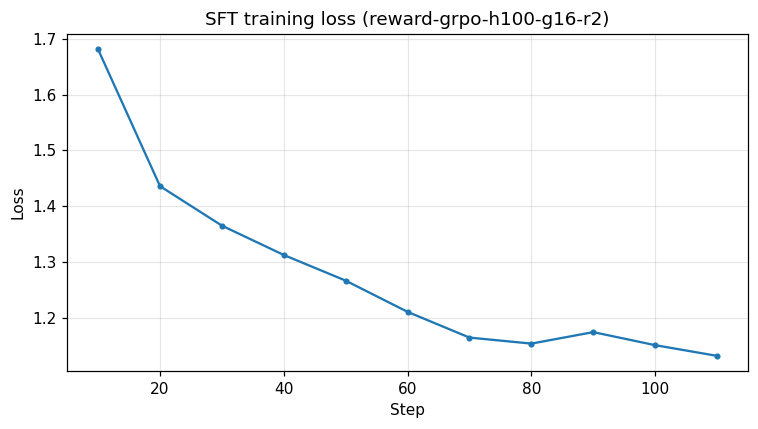

Saved: /share/mpsingh/fsaad/avcorp-runs/base-reward-grpo-h100-g16-r2/sft_loss_curve.png


In [25]:
%matplotlib inline
import matplotlib.pyplot as plt

# ---- figures: fixed Okabe-Ito colour per series, tuned for a white page
AVCORP_COLORS = ["#0072B2", "#D55E00", "#009E73", "#E69F00", "#CC79A7", "#56B4E9"]
STAGE_COLOR = {"base": "#0072B2", "sft": "#E69F00", "grpo": "#009E73"}
REF_GREY = "#6E6E6E"          # reference lines are not series: never a categorical hue

# corpus reference values from the gold-trace analysis
GOLD_GAME_END_EXACT = 0.932   # 233/250 games, both Evil named, no false accusation
GOLD_GAME_END_F1    = 0.962
GOLD_ROW_F1         = 0.841   # pooled over all 1,000 rows -- the SFT imitation ceiling
GOLD_F1_BY_ROUND    = {1: 0.691, 2: 0.816, 3: 0.906, 4: 0.930, 5: 0.980}
LOGIC_ONLY_EXACT    = 0.289  # guessing among the pairs the quest record allows
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


# HF Trainer already logs the SFT loss every 10 steps
_sft_hist = [h for h in sft_trainer.state.log_history if "loss" in h]
_sft_steps = [h["step"] for h in _sft_hist]
_sft_loss = [h["loss"] for h in _sft_hist]

plt.figure(figsize=(7, 4))
plt.plot(_sft_steps, _sft_loss, marker="o", markersize=3, color="tab:blue")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title(f"SFT training loss ({RUN_TAG})")
plt.grid(alpha=0.3)
plt.tight_layout()
_sft_fig_path = os.path.join(RUN_DIR, "sft_loss_curve.png")
plt.savefig(_sft_fig_path, dpi=150)
plt.show()
print(f"Saved: {_sft_fig_path}")


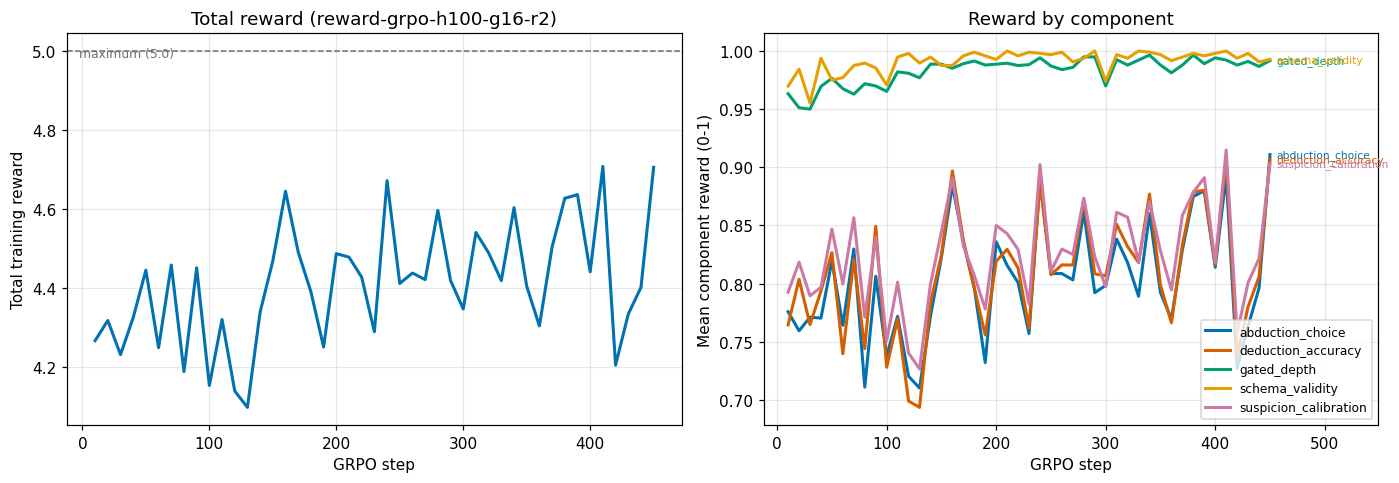

Saved: /share/mpsingh/fsaad/avcorp-runs/base-reward-grpo-h100-g16-r2/grpo_reward_curve.png


In [26]:
# Reward curves: the training objective, not a detection metric
_grpo_hist = [h for h in grpo_trainer.state.log_history if "reward" in h]
_grpo_steps = [h["step"] for h in _grpo_hist]
_grpo_reward = [h["reward"] for h in _grpo_hist]

_reward_component_keys = sorted({
    k for h in _grpo_hist for k in h
    if k.startswith("rewards/") and k.endswith("/mean")
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(_grpo_steps, _grpo_reward, color=AVCORP_COLORS[0], linewidth=2)
axes[0].axhline(len(_reward_component_keys), color=REF_GREY, linestyle="--", linewidth=1)
axes[0].annotate(f"maximum ({len(_reward_component_keys)}.0)", xy=(0.02, 0.94),
                 xycoords="axes fraction", fontsize=8, color=REF_GREY)
axes[0].set_xlabel("GRPO step")
axes[0].set_ylabel("Total training reward")
axes[0].set_title(f"Total reward ({RUN_TAG})")

for i, key in enumerate(_reward_component_keys):
    label = key.split("/")[1].replace("reward_", "")
    values = [h.get(key) for h in _grpo_hist]
    axes[1].plot(_grpo_steps, values, color=AVCORP_COLORS[i % len(AVCORP_COLORS)],
                 linewidth=2, label=label)
    # end labels, so identity does not rest on colour alone
    if values and values[-1] is not None:
        axes[1].annotate(label, xy=(_grpo_steps[-1], values[-1]), xytext=(4, 0),
                         textcoords="offset points", fontsize=7, va="center",
                         color=AVCORP_COLORS[i % len(AVCORP_COLORS)])
axes[1].set_xlabel("GRPO step")
axes[1].set_ylabel("Mean component reward (0-1)")
axes[1].set_title("Reward by component")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].set_xlim(right=_grpo_steps[-1] * 1.22 if _grpo_steps else None)

plt.tight_layout()
_grpo_fig_path = os.path.join(RUN_DIR, "grpo_reward_curve.png")
plt.savefig(_grpo_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {_grpo_fig_path}")


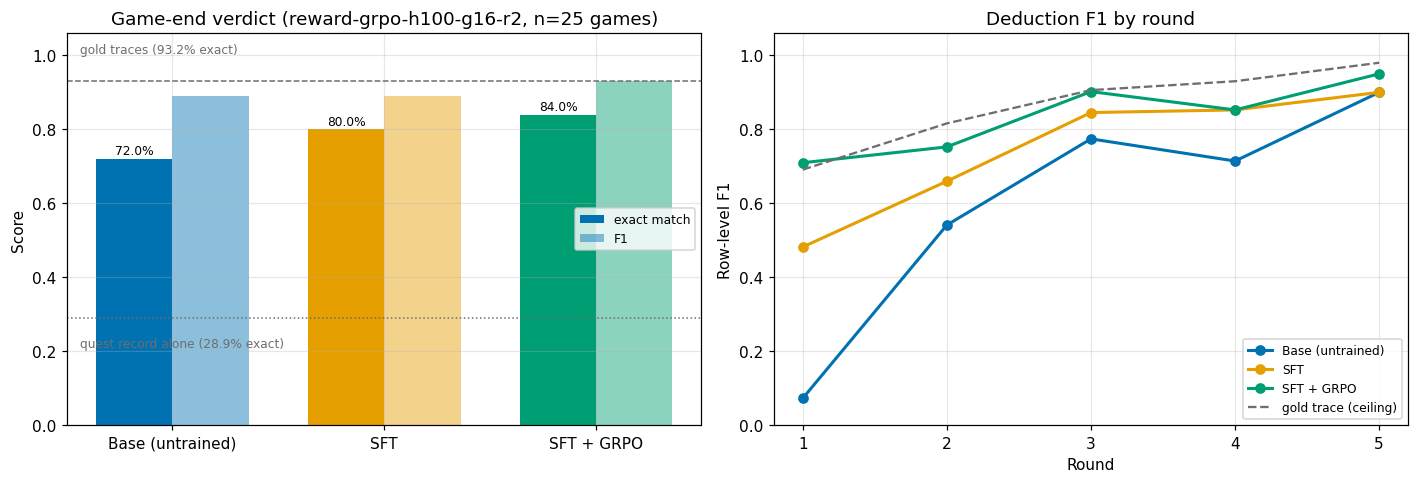

Saved: /share/mpsingh/fsaad/avcorp-runs/base-reward-grpo-h100-g16-r2/eval_comparison.png


In [27]:
# Evaluation figures
_stage_order = ["base", "sft", "grpo"]
_stage_labels = {"base": "Base (untrained)", "sft": "SFT", "grpo": "SFT + GRPO"}
_by_stage = {r["stage"]: r for r in results}
_present = [s for s in _stage_order if s in _by_stage]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# left: game-ending verdict, with the gold-trace ceiling and the logic-only floor
_x = range(len(_present))
_width = 0.36
axes[0].bar([i - _width/2 for i in _x], [_by_stage[s]["game_exact_match"] for s in _present],
            _width, color=[STAGE_COLOR[s] for s in _present], label="exact match")
axes[0].bar([i + _width/2 for i in _x], [_by_stage[s]["game_f1"] for s in _present],
            _width, color=[STAGE_COLOR[s] for s in _present], alpha=0.45, label="F1")
for i, s in enumerate(_present):
    axes[0].annotate(f"{_by_stage[s]['game_exact_match']:.1%}",
                     xy=(i - _width/2, _by_stage[s]["game_exact_match"]),
                     xytext=(0, 3), textcoords="offset points",
                     ha="center", fontsize=8)
axes[0].axhline(GOLD_GAME_END_EXACT, color=REF_GREY, linestyle="--", linewidth=1)
axes[0].annotate(f"gold traces ({GOLD_GAME_END_EXACT:.1%} exact)", xy=(0.02, 0.95),
                 xycoords="axes fraction", fontsize=8, color=REF_GREY)
axes[0].axhline(LOGIC_ONLY_EXACT, color=REF_GREY, linestyle=":", linewidth=1)
axes[0].annotate(f"quest record alone ({LOGIC_ONLY_EXACT:.1%} exact)", xy=(0.02, 0.20),
                 xycoords="axes fraction", fontsize=8, color=REF_GREY)
axes[0].set_xticks(list(_x))
axes[0].set_xticklabels([_stage_labels[s] for s in _present])
axes[0].set_ylim(0, 1.06)
axes[0].set_ylabel("Score")
axes[0].set_title(f"Game-end verdict ({RUN_TAG}, n={_by_stage[_present[-1]]['games']} games)")
axes[0].legend(fontsize=8, loc="center right")

# right: row-level F1 by round, gold traces dashed
_round_keys = sorted({int(k[len("f1_R"):]) for r in results for k in r if k.startswith("f1_R")})
for s in _present:
    r = _by_stage[s]
    xs = [rnd for rnd in _round_keys if f"f1_R{rnd}" in r]
    ys = [r[f"f1_R{rnd}"] for rnd in xs]
    if xs:
        axes[1].plot(xs, ys, marker="o", markersize=6, linewidth=2,
                     color=STAGE_COLOR[s], label=_stage_labels[s])
_gx = [rnd for rnd in _round_keys if rnd in GOLD_F1_BY_ROUND]
if _gx:
    axes[1].plot(_gx, [GOLD_F1_BY_ROUND[rnd] for rnd in _gx], linestyle="--",
                 linewidth=1.5, color=REF_GREY, label="gold trace (ceiling)")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Row-level F1")
axes[1].set_xticks(_round_keys)
axes[1].set_ylim(0, 1.06)
axes[1].set_title("Deduction F1 by round")
axes[1].legend(fontsize=8, loc="lower right")

plt.tight_layout()
_eval_fig_path = os.path.join(RUN_DIR, "eval_comparison.png")
plt.savefig(_eval_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {_eval_fig_path}")


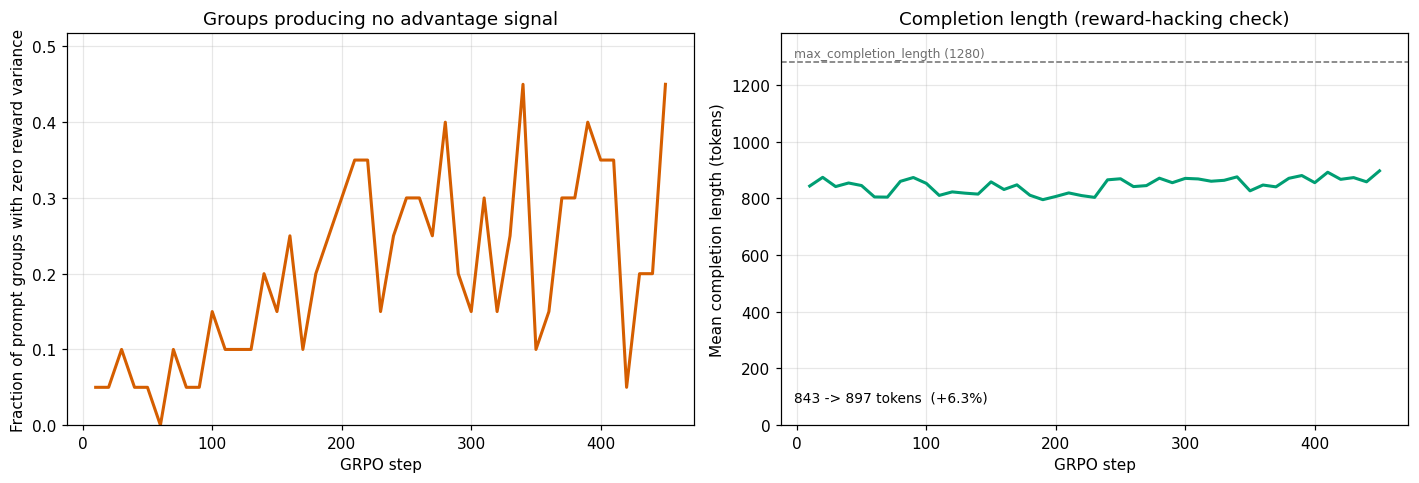

Saved: /share/mpsingh/fsaad/avcorp-runs/base-reward-grpo-h100-g16-r2/grpo_training_diagnostics.png


In [28]:
# Training diagnostics (not results)
_diag = [h for h in grpo_trainer.state.log_history if "reward" in h]
_dsteps = [h["step"] for h in _diag]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# left: share of prompt groups with zero reward variance (no gradient)
_zero = [h.get("frac_reward_zero_std") for h in _diag]
if any(v is not None for v in _zero):
    axes[0].plot(_dsteps, _zero, color=AVCORP_COLORS[1], linewidth=2)
    axes[0].set_ylim(0, max(0.5, max(v for v in _zero if v is not None) * 1.15))
    axes[0].set_ylabel("Fraction of prompt groups with zero reward variance")
else:
    axes[0].text(0.5, 0.5, "frac_reward_zero_std not logged by this TRL version",
                 ha="center", va="center", transform=axes[0].transAxes, fontsize=9)
axes[0].set_xlabel("GRPO step")
axes[0].set_title("Groups producing no advantage signal")

# right: completion length, to check for length hacking
_len = [h.get("completions/mean_length") for h in _diag]
if any(v is not None for v in _len):
    axes[1].plot(_dsteps, _len, color=AVCORP_COLORS[2], linewidth=2)
    axes[1].axhline(grpo_config.max_completion_length, color=REF_GREY,
                    linestyle="--", linewidth=1)
    axes[1].annotate(f"max_completion_length ({grpo_config.max_completion_length})",
                     xy=(0.02, 0.94), xycoords="axes fraction", fontsize=8, color=REF_GREY)
    _first = next(v for v in _len if v is not None)
    _last = next(v for v in reversed(_len) if v is not None)
    axes[1].annotate(f"{_first:.0f} -> {_last:.0f} tokens  ({(_last/_first - 1)*100:+.1f}%)",
                     xy=(0.02, 0.06), xycoords="axes fraction", fontsize=9)
    axes[1].set_ylim(0, grpo_config.max_completion_length * 1.08)
axes[1].set_xlabel("GRPO step")
axes[1].set_ylabel("Mean completion length (tokens)")
axes[1].set_title("Completion length (reward-hacking check)")

plt.tight_layout()
_diag_fig_path = os.path.join(RUN_DIR, "grpo_training_diagnostics.png")
plt.savefig(_diag_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {_diag_fig_path}")
